# Visual-language assistant with Gemma 4 and OpenVINO
![](https://ai.google.dev/gemma/images/gemma4_banner.png)

[Gemma 4](https://huggingface.co/collections/google/gemma-4) is Google DeepMind's latest generation of open multimodal models.
It handles **text and image** input (with **audio** on smaller models) and generates text output.

The family includes four sizes:

| Model | Total Params | Effective / Active | Modalities | Context | Architecture |
|---|---|---|---|---|---|
| **E2B** | 5.1 B | 2.3 B effective | Text, Image, Audio | 128 K | Dense + PLE |
| **E4B** | 8 B | 4.5 B effective | Text, Image, Audio | 128 K | Dense + PLE |
| **26B‑A4B** | 25.2 B | 3.8 B active | Text, Image | 256 K | MoE (8 / 128 experts + 1 shared) |
| **31B** | 30.7 B | 30.7 B | Text, Image | 256 K | Dense |

Key enhancements over Gemma 3:
- **Thinking mode** – built-in chain-of-thought reasoning via `enable_thinking=True`
- **Native system prompt** – first-class `system` role support
- **Interleaved multimodal input** – freely mix multiple images and text in any order
- **MoE architecture** – 26B‑A4B runs nearly as fast as a 4B model
- **Extended context** – up to 256 K tokens on larger models

In this notebook we will:
1. Export & compress a Gemma 4 model to OpenVINO IR with [Optimum Intel](https://github.com/huggingface/optimum-intel)
2. Run image-understanding inference via `OVModelForVisualCausalLM`
3. Demonstrate **native system prompt** support — control model persona via `system` role
4. Demonstrate **interleaved multi-image** input — compare and analyze multiple images
5. Demonstrate **thinking mode** (chain-of-thought reasoning)
6. Launch an interactive Gradio chat demo


#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Select model](#Select-model)
- [Convert and Optimize model](#Convert-and-Optimize-model)
  - [Select inference device](#Select-inference-device)
- [Run model inference](#Run-model-inference)
  - [Image understanding](#Image-understanding)
  - [Native system prompt](#Native-system-prompt)
  - [Interleaved multimodal input](#Interleaved-multimodal-input)
  - [Thinking mode](#Thinking-mode)
- [Interactive demo](#Interactive-demo)


⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO. It may be fully supported and validated in the future.

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).


<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/gemma4/gemma4.ipynb" />

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [ ]:
%pip uninstall -q -y optimum optimum-intel optimum-onnx
%pip install -q "git+https://github.com/rkazants/optimum-intel.git@support_gemma4" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -qU --pre "openvino" "nncf" --extra-index-url https://storage.openvinotoolkit.org/simple/wheels/nightly
%pip install -q "transformers==5.5.0"
%pip install -q "torch>=2.10" "torchvision" "Pillow" "gradio>=6.0" "opencv-python" "requests" "matplotlib" --extra-index-url https://download.pytorch.org/whl/cpu

In [2]:
from pathlib import Path
import requests

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

## Select model
[back to top ⬆️](#Table-of-contents:)

Several Gemma 4 instruction-tuned models are available in the [Gemma 4 collection](https://huggingface.co/collections/google/gemma-4).

| Model | Notes |
|---|---|
| `google/gemma-4-E2B-it` | 5.1 B total / 2.3 B effective, supports audio, best for quick testing |
| `google/gemma-4-E4B-it` | 8 B total / 4.5 B effective, supports audio |
| `google/gemma-4-26B-A4B-it` | 25.2 B total / 3.8 B active (MoE), fast inference |
| `google/gemma-4-31B-it` | 30.7 B dense, highest quality |

> **Note:** Larger models require significantly more RAM.

In [3]:
import ipywidgets as widgets

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("gemma4.ipynb")

model_ids = [
    "google/gemma-4-E2B-it",
    "google/gemma-4-E4B-it",
    "google/gemma-4-26B-A4B-it",
    "google/gemma-4-31B-it",
]

model_id = widgets.Dropdown(
    options=model_ids,
    default=model_ids[0],
    description="Model:",
)

model_id

Dropdown(description='Model:', options=('google/gemma-4-E2B-it', 'google/gemma-4-E4B-it', 'google/gemma-4-26B-…

In [4]:
print(f"Selected {model_id.value}")
pt_model_id = model_id.value
model_dir = Path(pt_model_id.split("/")[-1])

Selected google/gemma-4-E2B-it


## Convert and Optimize model
[back to top ⬆️](#Table-of-contents:)

Gemma 4 is a PyTorch model. We convert it to OpenVINO Intermediate Representation (IR) using
[🤗 Optimum Intel](https://huggingface.co/docs/optimum/intel/index) which provides a simple CLI:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> --weight-format <format> <output_dir>
```

Weight compression via [NNCF](https://github.com/openvinotoolkit/nncf) reduces model size with minimal quality loss, making it practical to run large models on consumer hardware. Available formats: **FP16** (no compression), **INT8** (~2× smaller), **INT4** (~4× smaller).

In [5]:
weight_format = widgets.Dropdown(
    options=["FP16", "INT8", "INT4"],
    value="INT8",
    description="Weight format:",
)

weight_format

Dropdown(description='Weight format:', index=1, options=('FP16', 'INT8', 'INT4'), value='INT8')

In [6]:
from cmd_helper import optimum_cli

model_export_dir = model_dir / weight_format.value

if not model_export_dir.exists():
    optimum_cli(pt_model_id, model_export_dir, additional_args={"task": "image-text-to-text", "weight-format": weight_format.value.lower()})

### Select inference device
[back to top ⬆️](#Table-of-contents:)

We use `OVModelForVisualCausalLM` from [Optimum Intel](https://huggingface.co/docs/optimum/intel/index)
for inference. It loads the exported OpenVINO IR model and provides a familiar
HuggingFace `generate()` API with automatic tokenization via `AutoProcessor`.

In [7]:
from notebook_utils import device_widget

device = device_widget(default="AUTO", exclude=["NPU", "GPU"])

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

## Run model inference
[back to top ⬆️](#Table-of-contents:)

In [8]:
from optimum.intel.openvino import OVModelForVisualCausalLM
from transformers import AutoProcessor
from PIL import Image

In [9]:
def load_image(path_or_url):
    import os
    from io import BytesIO

    if isinstance(path_or_url, str) and path_or_url.startswith(("http", "https")):
        import requests

        response = requests.get(path_or_url)
        if response.status_code != 200 or not response.content:
            raise FileNotFoundError(f"Could not retrieve image from URL: {path_or_url}")
        try:
            return Image.open(BytesIO(response.content)).convert("RGB")
        except Exception as e:
            raise FileNotFoundError(f"Failed to open image from URL: {path_or_url}") from e
    else:
        file_path = str(path_or_url)
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Image file does not exist: {file_path}")
        try:
            return Image.open(file_path).convert("RGB")
        except Exception as e:
            raise FileNotFoundError(f"Failed to open image file: {file_path}") from e


image_url = "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/d5fbbd1a-d484-415c-88cb-9986625b7b11"
image_file = Path("cat.png")

if not image_file.exists():
    image = load_image(image_url)
    image.save(image_file)
else:
    image = load_image(image_file)

In [10]:
processor = AutoProcessor.from_pretrained(model_export_dir)
model = OVModelForVisualCausalLM.from_pretrained(model_export_dir, device=device.value)

### Image understanding

Gemma 4 can analyze images at variable resolutions. Place image content **before** text
in the prompt for best results.

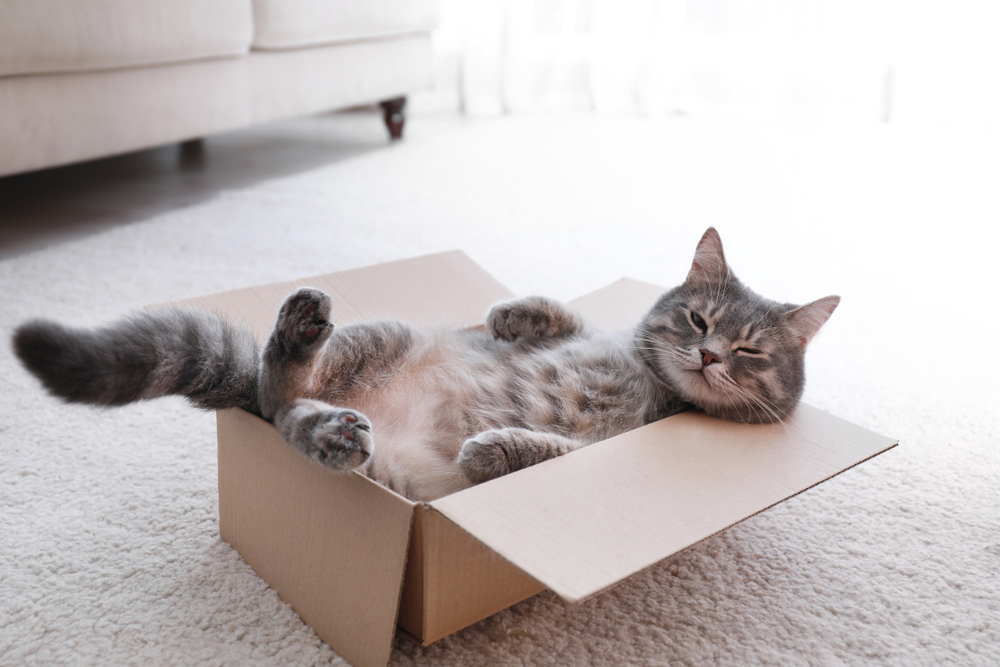

The image shows a **cat lying comfortably inside a cardboard box** on a light-colored, shaggy rug.

What is **unusual** about this image is the **context** or the **situation**:

1.  **The Cat's Placement:** Cats are typically creatures of comfort and independence. Being placed inside a box, especially if it's a temporary container, can be unusual or suggest a specific scenario (like moving, a temporary hiding spot, or a playful setup).
2.  **The Box as a Bed:** While cats sometimes use boxes for hiding, using a cardboard box as a cozy bed is a somewhat anthropomorphic or staged element, making the scene endearing rather than strictly natural.

Overall, the image is **whimsical and cute** because of the juxtaposition of the domestic animal (the cat) with the mundane object (the cardboard box).


In [12]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Describe what is unusual in these images."},
        ],
    }
]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
inputs = processor(text=text, images=[image], return_tensors="pt")
input_len = inputs["input_ids"].shape[-1]

display(image)
output = model.generate(**inputs, do_sample=False, max_new_tokens=200)
response = processor.decode(output[0][input_len:], skip_special_tokens=True)
print(response)

### Native system prompt

Unlike Gemma 3, Gemma 4 introduces first-class support for the **`system` role**.
This allows you to control the model's persona and behavior by adding a `system`
message at the start of the conversation — no need to embed instructions in the user message.

Let's try it — we'll give the model a professional art-critic persona and see how it changes the response.

In [13]:
# Gemma 4 natively supports the system role
messages = [
    {
        "role": "system",
        "content": "You are a professional art critic. Analyze visual compositions with attention to color, form, and emotional impact. Be concise.",
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What do you see in this image? Answer in 2-3 short paragraphs."},
        ],
    },
]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
inputs = processor(text=text, images=[image], return_tensors="pt")
input_len = inputs["input_ids"].shape[-1]

output = model.generate(**inputs, do_sample=False, max_new_tokens=200)
response = processor.decode(output[0][input_len:], skip_special_tokens=True)
print(response)

This image presents a soft, intimate scene dominated by a domestic cat resting within a simple cardboard box. The composition is bright and airy, characterized by a high-key lighting scheme that washes the scene in a gentle, almost ethereal glow. The texture of the thick, white, shaggy carpet provides a soft, neutral foundation, contrasting subtly with the muted, earthy tone of the cardboard.

The cat itself is the focal point, rendered in shades of cool gray and silver tabby markings. Its posture is one of complete relaxation—stretched out and seemingly content—lending the image a strong sense of tranquility and vulnerability. The soft forms of the cat are juxtaposed against the rigid, geometric lines of the box, creating an interesting tension between organic softness and manufactured structure.

Emotionally, the photograph evokes a feeling of quiet comfort and peaceful repose. The overall aesthetic is minimalist yet warm, using the interplay of soft textures and muted colors to crea

### Interleaved multimodal input

Gemma 4 can process **multiple images freely mixed with text** in a single prompt.
This enables tasks like visual comparison, multi-page document analysis, and combining information from several sources.

Let's download a second image and ask the model to compare both.

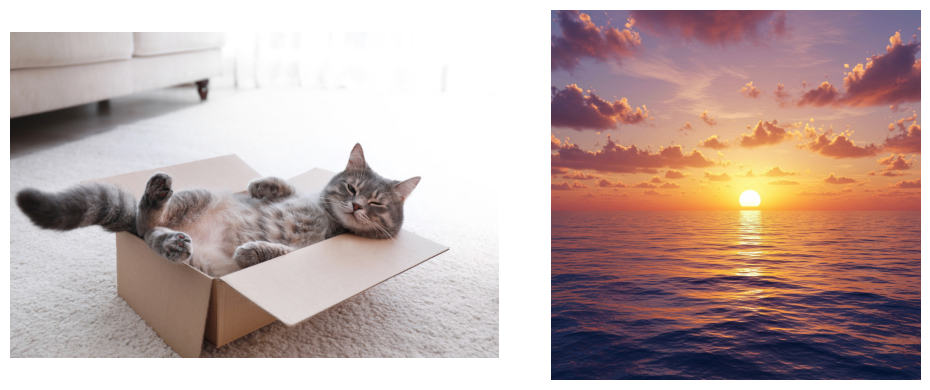

Here is a comparison of the two images:

**Image 1 Description:**
This image features a domestic cat with gray and white fur lying comfortably inside a plain cardboard box. The box is resting on a very light, fluffy, white or cream-colored carpet. In the background, there is a glimpse of light-colored, upholstered furniture (likely a sofa). The lighting is bright and soft, suggesting an indoor setting.

**Image 2 Description:**
This image is a landscape photograph of a sunset over the ocean. The sky is filled with vibrant colors, including shades of orange, pink, purple, and yellow, with scattered clouds. The sun is setting directly over the horizon, casting a bright, shimmering reflection (sun path) across the water. The ocean water reflects these warm tones, creating a rich, reddish-orange hue.

**Color Palette Comparison:**

The **second image (the sunset over the ocean)** has a significantly **warmer color palette**. It is dominated by warm tones like orange, pink, gold, and deep r

In [14]:
import matplotlib.pyplot as plt

image2_url = "https://github.com/user-attachments/assets/da3edb79-ae36-4973-9eaf-6ef712425faa"
image2_file = Path("sunset.png")

if not image2_file.exists():
    image2 = load_image(image2_url)
    image2.save(image2_file)
else:
    image2 = load_image(image2_file)

# Pass multiple images — Gemma 4 handles interleaved multimodal input
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "image", "image": image2},
            {"type": "text", "text": "I have two images. Compare them: describe what you see in each and which image has a warmer color palette."},
        ],
    }
]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
inputs = processor(text=text, images=[image, image2], return_tensors="pt")
input_len = inputs["input_ids"].shape[-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(image)
ax1.axis("off")
ax2.imshow(image2)
ax2.axis("off")
plt.tight_layout()
plt.show()

output = model.generate(**inputs, do_sample=False, max_new_tokens=300)
response = processor.decode(output[0][input_len:], skip_special_tokens=True)
print(response)

### Thinking mode

Gemma 4 supports built-in **chain-of-thought reasoning**. Setting `enable_thinking=True`
in `apply_chat_template` adds the `<|think|>` token to the system prompt, which triggers the model to reason internally before producing a final answer.

When thinking is enabled, the model outputs its reasoning using
[control tokens](https://huggingface.co/google/gemma-4-E2B-it#2-thinking-mode-configuration):
```
<|channel>thought
[internal reasoning]
<channel|>
[final answer]
```

`processor.parse_response()` parses this structure and returns a dict with `thinking` and `content` keys.

In [15]:
# Enable thinking mode via enable_thinking=True in chat template
messages = [
    {"role": "system", "content": "You are a helpful assistant. Think step by step before answering."},
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Look at this image. Count all the visible animals and describe each one."},
        ],
    },
]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=True)
inputs = processor(text=text, images=[image], return_tensors="pt")
input_len = inputs["input_ids"].shape[-1]

output = model.generate(**inputs, do_sample=False, max_new_tokens=500)
response = processor.decode(output[0][input_len:], skip_special_tokens=False)

parsed = processor.parse_response(response)

if parsed.get("thinking"):
    print("=== Thinking ===")
    print(parsed["thinking"])
    print()

print("=== Answer ===")
print(parsed["content"])

=== Thinking ===
Here's a thinking process to arrive at the desired response:

1.  **Analyze the Request:** The user wants me to look at the provided image and perform two tasks:
    *   Count all the visible animals.
    *   Describe each one.

2.  **Examine the Image:** I need to scan the image carefully to identify anything that qualifies as an animal.
    *   The main subject is a cat.
    *   The cat is lying inside a cardboard box on a white, fluffy rug.

3.  **Identify and Count Animals:**
    *   Is there a dog? No.
    *   Is there a bird? No.
    *   Is there a cat? Yes, one.
    *   Total count: 1.

4.  **Describe the Animal(s):** I need to provide a detailed description of the cat visible in the picture.
    *   **Type:** Domestic cat.
    *   **Appearance (Color/Pattern):** It has tabby markings (grey/brown stripes/patches). It looks grey and silver/white.
    *   **Pose/Action:** It is lying down, relaxed, or sleeping, nestled inside a cardboard box. Its tail is extended 

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [ ]:
if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/gemma4/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

In [ ]:
from gradio_helper import make_demo

demo = make_demo(model, processor)

try:
    demo.launch(debug=True, height=900)
except Exception:
    demo.launch(share=True, debug=True, height=900)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/